# Step 55a — Single-feature OLS bridge (dispersion vs daily_zpnl)

Not a discovery step -- dispersion is already known from `#54` to fail the screen.
Purpose: (1) show a fitted OLS regression is numerically *equivalent* to `#54`'s
manual Pearson-r screening for one feature, (2) build the reusable pipeline `#55b`
(multi-feature + Ridge + CV) extends.

**NaN-drop scope (pinned per plan review): dispersion + daily_zpnl only** (n~2497),
matching `#54`'s original 2-feature-sample reference r=0.0565 -- NOT the wider
13-feature-sample r=0.0575 (a different, also-correct, but different sample).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
plt.style.use('dark_background')

np.random.seed(42)
FEATURE = 'dispersion'


## 1. Data: aggregate to daily, dispersion + daily_zpnl only

In [2]:
trades = pd.read_csv('54c_trade_log_with_features.csv', parse_dates=['signal_dt'])
trades['date'] = trades['signal_dt'].dt.date

daily = trades.groupby('date').agg(daily_zpnl=('zpnl', 'sum'), dispersion=('dispersion', 'first')).reset_index()
daily = daily.dropna(subset=[FEATURE, 'daily_zpnl']).sort_values('date').reset_index(drop=True)
n = len(daily)
print(f'n = {n} trading days ({daily.date.min()} -> {daily.date.max()})')
daily.head()


n = 2497 trading days (2015-02-04 -> 2026-08-31)


,date,daily_zpnl,dispersion
0,2015-02-04,-6.5162,2.858778
1,2015-02-05,1.2407,2.103408
2,2015-02-09,1.6365,1.907490
3,2015-02-11,5.7317,2.309467
4,2015-02-12,-2.1963,1.790855


## 2. Manual Pearson r -- should reproduce #54's reference (r=0.0565, n~2497)

In [3]:
x = daily[FEATURE].values.astype(float)
y = daily['daily_zpnl'].values.astype(float)

r_manual = np.corrcoef(x, y)[0, 1]
print(f'r(dispersion, daily_zpnl) = {r_manual:.4f}   (n={n})')
print(f'#54 reference: r=0.0565 @ n~2497')

REF_R, REF_N = 0.0565, 2497
if abs(r_manual - REF_R) > 0.002 or abs(n - REF_N) > 5:
    raise AssertionError(
        f'PIPELINE MISMATCH: r={r_manual:.4f} (n={n}) does not match #54 reference '
        f'r={REF_R} (n={REF_N}) within tolerance -- STOP, report before continuing.')
print('\nMATCHES #54 reference within tolerance -- pipeline confirmed consistent.')


r(dispersion, daily_zpnl) = 0.0565   (n=2497)
#54 reference: r=0.0565 @ n~2497

MATCHES #54 reference within tolerance -- pipeline confirmed consistent.


## 3. OLS by hand, then cross-checked against a library

x̄, ȳ, Sxx=Σ(x−x̄)², Sxy=Σ(x−x̄)(y−ȳ), Syy=Σ(y−ȳ)², b1=Sxy/Sxx, b0=ȳ−b1·x̄, ŷ,
residuals e, σ̂²=Σe²/(n−2), SE(b1)=√(σ̂²/Sxx), t=b1/SE(b1), p (two-sided, t-dist n−2 df),
R²=1−Σe²/Syy.

In [4]:
xbar, ybar = x.mean(), y.mean()
Sxx = np.sum((x - xbar)**2)
Sxy = np.sum((x - xbar) * (y - ybar))
Syy = np.sum((y - ybar)**2)

b1 = Sxy / Sxx
b0 = ybar - b1 * xbar
yhat = b0 + b1 * x
e = y - yhat
SSE = np.sum(e**2)
sigma2_hat = SSE / (n - 2)
SE_b1 = np.sqrt(sigma2_hat / Sxx)
t_stat = b1 / SE_b1
p_formula = 2 * stats.t.sf(abs(t_stat), n - 2)
R2 = 1 - SSE / Syy

print(f'xbar={xbar:.4f}  ybar={ybar:.4f}')
print(f'Sxx={Sxx:.2f}  Sxy={Sxy:.2f}  Syy={Syy:.2f}')
print(f'b1={b1:.6f}  b0={b0:.6f}')
print(f'SSE={SSE:.2f}  sigma2_hat={sigma2_hat:.4f}')
print(f'SE(b1)={SE_b1:.6f}  t={t_stat:.4f}  p={p_formula:.6f}')
print(f'R^2={R2:.6f}')

# cross-check against library
slope_lib, intercept_lib, r_lib, p_lib, se_lib = stats.linregress(x, y)
print('\n--- cross-check: scipy.stats.linregress ---')
print(f'slope={slope_lib:.6f}  intercept={intercept_lib:.6f}  r={r_lib:.6f}  p={p_lib:.6f}  SE(slope)={se_lib:.6f}')

assert abs(b1 - slope_lib) < 1e-9, 'b1 mismatch vs library'
assert abs(b0 - intercept_lib) < 1e-9, 'b0 mismatch vs library'
assert abs(SE_b1 - se_lib) < 1e-9, 'SE(b1) mismatch vs library'
assert abs(p_formula - p_lib) < 1e-6, 'p mismatch vs library'
print('\nHand-derived OLS matches scipy.stats.linregress exactly.')


xbar=1.6427  ybar=-0.9950
Sxx=1249.79  Sxy=1665.56  Syy=694215.36
b1=1.332674  b0=-3.184217
SSE=691995.70  sigma2_hat=277.3530
SE(b1)=0.471083  t=2.8290  p=0.004707
R^2=0.003197

--- cross-check: scipy.stats.linregress ---
slope=1.332674  intercept=-3.184217  r=0.056545  p=0.004707  SE(slope)=0.471083

Hand-derived OLS matches scipy.stats.linregress exactly.


## 4. Equivalence checks (r <-> OLS) -- the core teaching point of 55a

In [5]:
r_from_b1 = b1 * np.sqrt(Sxx / Syy)
r_from_R2 = np.sign(b1) * np.sqrt(R2)
t_from_r = r_manual * np.sqrt(n - 2) / np.sqrt(1 - r_manual**2)

print(f'{'quantity':<35}{'value':>12}')
print(f'{'r (Pearson, cell 2)':<35}{r_manual:>12.6f}')
print(f'{'r = b1 * sqrt(Sxx/Syy)':<35}{r_from_b1:>12.6f}')
print(f'{'r = sign(b1) * sqrt(R^2)':<35}{r_from_R2:>12.6f}')
print()
print(f'{'t-stat from b1/SE(b1)':<35}{t_stat:>12.6f}')
print(f'{'t-stat from r*sqrt(n-2)/sqrt(1-r^2)':<35}{t_from_r:>12.6f}')

assert abs(r_manual - r_from_b1) < 1e-9
assert abs(r_manual - r_from_R2) < 1e-9
assert abs(t_stat - t_from_r) < 1e-9
print('\nAll match to floating-point precision -- r-based screening and OLS are the same test.')


quantity                                  value
r (Pearson, cell 2)                    0.056545
r = b1 * sqrt(Sxx/Syy)                 0.056545
r = sign(b1) * sqrt(R^2)               0.056545

t-stat from b1/SE(b1)                  2.828956
t-stat from r*sqrt(n-2)/sqrt(1-r^2)    2.828956

All match to floating-point precision -- r-based screening and OLS are the same test.


## 5. Significance: formula p vs robust (circular-shift), residual acf1, HAC SE

In [6]:
def individual_null_circular(x_arr, y_arr):
    n_ = len(y_arr)
    null_r = np.empty(n_ - 1)
    for shift in range(1, n_):
        null_r[shift - 1] = np.corrcoef(x_arr, np.roll(y_arr, shift))[0, 1]
    return null_r

null_dist = individual_null_circular(x, y)
ceil95, ceil99 = np.percentile(np.abs(null_dist), [95, 99])
emp_p = (np.abs(null_dist) >= abs(r_manual)).mean()

resid_acf1 = np.corrcoef(e[:-1], e[1:])[0, 1]

print(f'formula p (t-dist, n-2 df)      = {p_formula:.6f}')
print(f'circular-shift empirical p     = {emp_p:.6f}  (ceil95={ceil95:.4f}, ceil99={ceil99:.4f})')
print(f'residual acf1                  = {resid_acf1:.4f}')
print(f'#54 max-of-13 ceiling (ref, not recomputed): ceil95=0.0637, ceil99=0.0812')
print(f'  -> real r={r_manual:.4f} vs max-of-13: clears95={abs(r_manual)>0.0637}, clears99={abs(r_manual)>0.0812}')

try:
    import statsmodels.api as sm
    X_sm = sm.add_constant(x)
    ols_res = sm.OLS(y, X_sm).fit()
    hac_res = sm.OLS(y, X_sm).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    print(f'\nstatsmodels naive SE(b1) = {ols_res.bse[1]:.6f}  (matches hand-derived: {abs(ols_res.bse[1]-SE_b1)<1e-6})')
    print(f'statsmodels Newey-West HAC SE(b1) (maxlags=5) = {hac_res.bse[1]:.6f}')
    print(f'HAC/naive SE ratio = {hac_res.bse[1]/ols_res.bse[1]:.3f} '
          f'({"wider" if hac_res.bse[1]>ols_res.bse[1] else "narrower"} -- naive formula SE '
          f'{"is too optimistic" if hac_res.bse[1]>ols_res.bse[1] else "was fine"} given residual autocorrelation)')
except ImportError:
    print('\nstatsmodels not available -- skipping HAC SE comparison.')


formula p (t-dist, n-2 df)      = 0.004707
circular-shift empirical p     = 0.018830  (ceil95=0.0464, ceil99=0.0632)
residual acf1                  = 0.0184
#54 max-of-13 ceiling (ref, not recomputed): ceil95=0.0637, ceil99=0.0812
  -> real r=0.0565 vs max-of-13: clears95=False, clears99=False



statsmodels naive SE(b1) = 0.471083  (matches hand-derived: True)
statsmodels Newey-West HAC SE(b1) (maxlags=5) = 0.744611
HAC/naive SE ratio = 1.581 (wider -- naive formula SE is too optimistic given residual autocorrelation)


## 6. OOS: chronological 70/30 split, fit on TRAIN, predict on TEST

Rule: trade only on days where TRAIN-fit b0+b1*x predicts daily_zpnl > 0.
OOS R^2 uses TRAIN's mean of y for SST (not TEST's own mean) -- confirmed correct by
plan review: this is the standard genuine-OOS-R^2 convention (Campbell-Thompson style)
-- using TEST's own mean would hand the naive baseline foreknowledge it wouldn't
really have.

In [7]:
def zpf(z):
    pos = z[z > 0].sum(); neg = z[z < 0].sum()
    return pos / abs(neg) if neg != 0 else np.nan

split_idx = int(n * 0.70)
train = daily.iloc[:split_idx]
test = daily.iloc[split_idx:]
print(f'Train: {len(train)} days ({train.date.min()} -> {train.date.max()})')
print(f'Test:  {len(test)} days ({test.date.min()} -> {test.date.max()})')

x_tr, y_tr = train[FEATURE].values.astype(float), train['daily_zpnl'].values.astype(float)
x_te, y_te = test[FEATURE].values.astype(float), test['daily_zpnl'].values.astype(float)

Sxx_tr = np.sum((x_tr - x_tr.mean())**2)
Sxy_tr = np.sum((x_tr - x_tr.mean()) * (y_tr - y_tr.mean()))
b1_tr = Sxy_tr / Sxx_tr
b0_tr = y_tr.mean() - b1_tr * x_tr.mean()
print(f'\nTRAIN-fit: b0={b0_tr:.4f}  b1={b1_tr:.6f}')

yhat_te = b0_tr + b1_tr * x_te
predicted_positive = yhat_te > 0
pct_positive = predicted_positive.mean()
print(f'\n%% of TEST days predicted positive: {pct_positive:.1%}'
      f'  ({'INTERCEPT-DOMINATED -- b1 tiny, nearly every day gets the same sign' if pct_positive > 0.97 or pct_positive < 0.03 else 'mixed calls, not intercept-dominated'})')

traded = test[predicted_positive]
print(f'\nTraded (predicted-positive) days: {len(traded)}, ZPF={zpf(traded["daily_zpnl"]):.3f}, '
      f'net={traded["daily_zpnl"].sum():.0f}')
print(f'All TEST days (baseline):          {len(test)}, ZPF={zpf(test["daily_zpnl"]):.3f}, '
      f'net={test["daily_zpnl"].sum():.0f}')

SSE_test = np.sum((y_te - yhat_te)**2)
SST_test_trainmean = np.sum((y_te - y_tr.mean())**2)
R2_oos = 1 - SSE_test / SST_test_trainmean
print(f'\nOOS R^2 (SST using TRAIN mean) = {R2_oos:.6f}'
      f'  ({'model beats train-mean baseline on unseen data' if R2_oos > 0 else 'model WORSE than just predicting the train mean -- negative OOS R^2'})')


Train: 1747 days (2015-02-04 -> 2023-04-11)
Test:  750 days (2023-04-12 -> 2026-08-31)

TRAIN-fit: b0=-2.2046  b1=1.154600

%% of TEST days predicted positive: 11.5%  (mixed calls, not intercept-dominated)

Traded (predicted-positive) days: 86, ZPF=0.753, net=-234
All TEST days (baseline):          750, ZPF=0.637, net=-2185

OOS R^2 (SST using TRAIN mean) = 0.004190  (model beats train-mean baseline on unseen data)


## 7. Chart: dispersion vs daily_zpnl, TRAIN-fit line, train/test distinguished

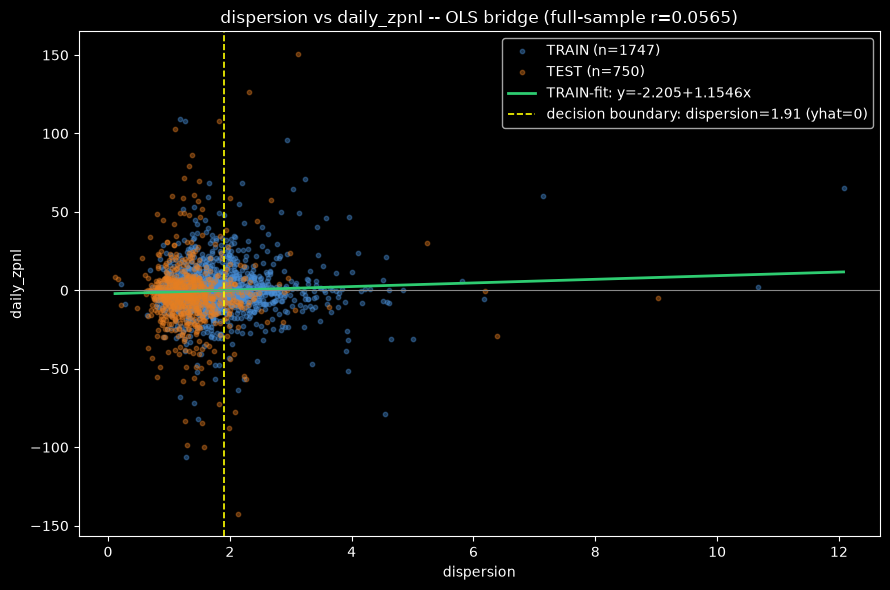

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(9, 6))
ax.scatter(x_tr, y_tr, s=10, alpha=0.4, color='#4a90d9', label=f'TRAIN (n={len(train)})')
ax.scatter(x_te, y_te, s=10, alpha=0.4, color='#e67e22', label=f'TEST (n={len(test)})')
xline = np.linspace(daily[FEATURE].min(), daily[FEATURE].max(), 100)
ax.plot(xline, b0_tr + b1_tr * xline, color='#2ecc71', linewidth=2,
        label=f'TRAIN-fit: y={b0_tr:.3f}+{b1_tr:.4f}x')
ax.axhline(0, color='#888', linewidth=0.8)
ax.axvline(-b0_tr / b1_tr, color='yellow', linewidth=1.2, linestyle='--',
           label=f'decision boundary: dispersion={-b0_tr / b1_tr:.2f} (yhat=0)')
ax.set_xlabel(FEATURE); ax.set_ylabel('daily_zpnl')
ax.set_title(f'{FEATURE} vs daily_zpnl -- OLS bridge (full-sample r={r_manual:.4f})')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Two-feature visual (dispersion + gap_pct) -- comparison chart only, NOT a screen

Purely visual: how does adding a second feature (gap_pct, #54's single strongest |r|,
not a volatility twin of dispersion the way india_vix_level is) change the picture
next to Section 7's one-feature chart? No significance testing, no verdict here --
`#55b` does pairs with full rigor (null-calibration, proper OOS gate) later.

`gap_pct` is same-day-but-pre-signal (open vs prior close, computed before any of
today's intraday signals fire per `54c_regime_features.py`) -- safe to use as-is,
same as every other #54 screen.

In [9]:
FEATURE2 = 'gap_pct'
daily2 = trades.groupby('date').agg(
    daily_zpnl=('zpnl', 'sum'), dispersion=('dispersion', 'first'), gap_pct=('gap_pct', 'first')
).reset_index()
daily2 = daily2.dropna(subset=[FEATURE, FEATURE2, 'daily_zpnl']).sort_values('date').reset_index(drop=True)
n2 = len(daily2)
print(f'n = {n2} trading days ({daily2.date.min()} -> {daily2.date.max()})')

split_idx2 = int(n2 * 0.70)
train2 = daily2.iloc[:split_idx2]
test2 = daily2.iloc[split_idx2:]
print(f'Train: {len(train2)} days, Test: {len(test2)} days')

X_tr2 = train2[[FEATURE, FEATURE2]].values.astype(float)
y_tr2 = train2['daily_zpnl'].values.astype(float)
X_te2 = test2[[FEATURE, FEATURE2]].values.astype(float)
y_te2 = test2['daily_zpnl'].values.astype(float)

# OLS via normal equations (TRAIN only): yhat = b0 + b1*x1 + b2*x2
A = np.column_stack([np.ones(len(X_tr2)), X_tr2])
coefs, *_ = np.linalg.lstsq(A, y_tr2, rcond=None)
b0_2, b1_2, b2_2 = coefs
print(f'\nTRAIN-fit: b0={b0_2:.4f}  b1(dispersion)={b1_2:.6f}  b2(gap_pct)={b2_2:.6f}')

yhat_tr2 = A @ coefs
r2_in_sample = 1 - np.sum((y_tr2 - yhat_tr2)**2) / np.sum((y_tr2 - y_tr2.mean())**2)

A_te = np.column_stack([np.ones(len(X_te2)), X_te2])
yhat_te2 = A_te @ coefs
SSE_te2 = np.sum((y_te2 - yhat_te2)**2)
SST_te2_trainmean = np.sum((y_te2 - y_tr2.mean())**2)
r2_oos2 = 1 - SSE_te2 / SST_te2_trainmean

pred_pos2 = (yhat_te2 > 0).mean()
print(f'In-sample R^2 (TRAIN) = {r2_in_sample:.6f}')
print(f'OOS R^2 (TEST, SST via TRAIN mean) = {r2_oos2:.6f}')
print(f'%% of TEST days predicted positive = {pred_pos2:.1%}')


n = 2495 trading days (2015-02-04 -> 2026-08-31)
Train: 1746 days, Test: 749 days

TRAIN-fit: b0=-2.2436  b1(dispersion)=1.291786  b2(gap_pct)=-0.979294
In-sample R^2 (TRAIN) = 0.004813
OOS R^2 (TEST, SST via TRAIN mean) = 0.009459
%% of TEST days predicted positive = 16.4%


### 8A. Static PNG -- same format as Section 7, for direct side-by-side comparison

A 2-feature model has no single x-axis to plot against -- use the combined prediction
ŷ instead. The green line here (y=ŷ) is the exact analog of Section 7's fit line: the
in-sample OLS fit of actual y on predicted ŷ is that diagonal by construction. The
vertical line at ŷ=0 is the decision-boundary analog of Section 7's crossing point.

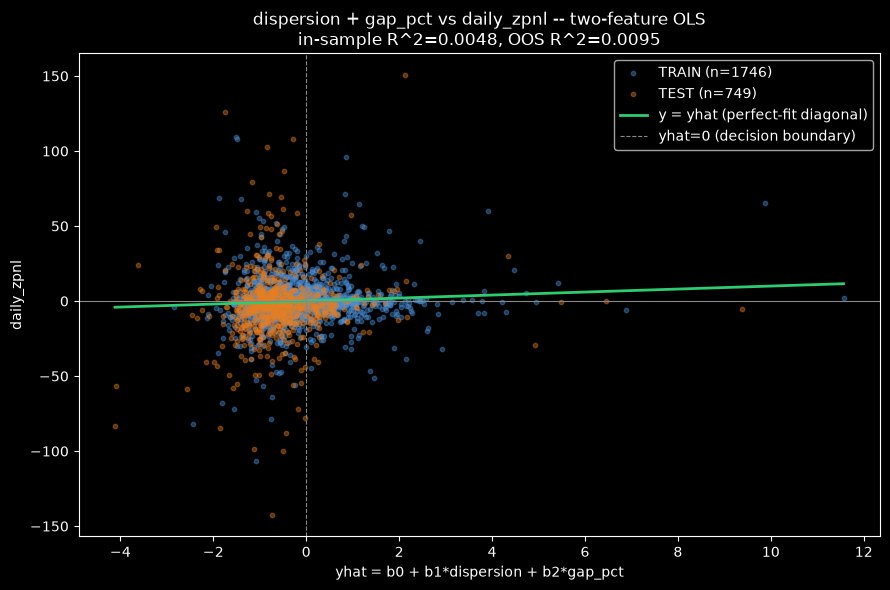

Saved: 55a_two_feature_static.png


In [10]:
fig, ax = plt.subplots(1, 1, figsize=(9, 6))
ax.scatter(yhat_tr2, y_tr2, s=10, alpha=0.4, color='#4a90d9', label=f'TRAIN (n={len(train2)})')
ax.scatter(yhat_te2, y_te2, s=10, alpha=0.4, color='#e67e22', label=f'TEST (n={len(test2)})')
yhat_line = np.linspace(min(yhat_tr2.min(), yhat_te2.min()), max(yhat_tr2.max(), yhat_te2.max()), 100)
ax.plot(yhat_line, yhat_line, color='#2ecc71', linewidth=2, label='y = yhat (perfect-fit diagonal)')
ax.axhline(0, color='#888', linewidth=0.8)
ax.axvline(0, color='#888', linewidth=0.8, linestyle='--', label='yhat=0 (decision boundary)')
ax.set_xlabel('yhat = b0 + b1*dispersion + b2*gap_pct'); ax.set_ylabel('daily_zpnl')
ax.set_title(f'dispersion + gap_pct vs daily_zpnl -- two-feature OLS\n'
             f'in-sample R^2={r2_in_sample:.4f}, OOS R^2={r2_oos2:.4f}')
ax.legend()
plt.tight_layout()
plt.savefig('55a_two_feature_static.png', dpi=130)
plt.show()
print('Saved: 55a_two_feature_static.png')


### 8B. Interactive 3D (Plotly) -- same fit, same data

In [11]:
import plotly.graph_objects as go

x1_range = np.linspace(daily2[FEATURE].min(), daily2[FEATURE].max(), 30)
x2_range = np.linspace(daily2[FEATURE2].min(), daily2[FEATURE2].max(), 30)
X1_grid, X2_grid = np.meshgrid(x1_range, x2_range)
Z_grid = b0_2 + b1_2 * X1_grid + b2_2 * X2_grid

fig3d = go.Figure()

fig3d.add_trace(go.Surface(x=x1_range, y=x2_range, z=Z_grid, opacity=0.45,
                            colorscale='Oranges', showscale=False, name='TRAIN-fit plane'))

# z=0 reference plane
Z0 = np.zeros_like(Z_grid)
fig3d.add_trace(go.Surface(x=x1_range, y=x2_range, z=Z0, opacity=0.12,
                            colorscale=[[0, 'gray'], [1, 'gray']], showscale=False, name='z=0 reference'))

# decision boundary: yhat=0 -> gap_pct = -(b0+b1*x1)/b2, clipped to plotted gap_pct range
if abs(b2_2) > 1e-12:
    boundary_x2 = -(b0_2 + b1_2 * x1_range) / b2_2
    mask = (boundary_x2 >= daily2[FEATURE2].min()) & (boundary_x2 <= daily2[FEATURE2].max())
    fig3d.add_trace(go.Scatter3d(x=x1_range[mask], y=boundary_x2[mask], z=np.zeros(mask.sum()),
                                  mode='lines', line=dict(color='yellow', width=8),
                                  name='decision boundary (yhat=0)'))

for label, d, color in [('TRAIN', train2, '#4a90d9'), ('TEST', test2, '#e67e22')]:
    fig3d.add_trace(go.Scatter3d(
        x=d[FEATURE], y=d[FEATURE2], z=d['daily_zpnl'], mode='markers',
        marker=dict(size=3, color=color, opacity=0.7), name=f'{label} (n={len(d)})',
        customdata=np.stack([d['date'].astype(str)], axis=-1),
        hovertemplate='date=%{customdata[0]}<br>dispersion=%{x:.3f}<br>gap_pct=%{y:.3f}<br>daily_zpnl=%{z:.2f}<extra></extra>'
    ))

fig3d.update_layout(
    title=f'yhat = {b0_2:.3f} + {b1_2:.4f}*dispersion + {b2_2:.4f}*gap_pct<br>'
          f'In-sample R^2={r2_in_sample:.4f}, OOS R^2={r2_oos2:.4f}',
    scene=dict(xaxis_title='dispersion', yaxis_title='gap_pct', zaxis_title='daily_zpnl'),
    width=900, height=700
)
fig3d.write_html('55a_two_feature_plane.html')
fig3d.show()
print('Saved: 55a_two_feature_plane.html')


Saved: 55a_two_feature_plane.html


# Sections 9-13 — Full 12-step template, TRAIN-gated (dispersion only)

`#55b` is ON HOLD -- Saurav's decision is to complete the full 12-step template on
dispersion alone first. Sections 1-8B above are left as labelled FULL-sample
reference (steps 1-9 there run on all ~2497 days, not the fit sample) -- the sections
below redo the gating steps correctly on TRAIN only, per the earlier plan review:

**Plan-review fix applied**: `#54`'s max-of-13 ceiling (0.0637/0.0812) was derived on
the FULL sample (n~2497) -- applying it as a hard pass/fail bar to `r_train` (n=1747,
a smaller sample with a genuinely different, likely wider, null spread) would risk a
false pass. Kept as **informational context only** in Section 9/13, not a hard
AND-condition -- Section 9's own freshly-computed circular-shift p (correctly
calibrated to TRAIN's own n) is the authoritative significance test, consistent with
how every #54 screen worked.

## 9. Steps 1-9 on TRAIN only

The current sections 3-5 above ran steps 1-9 on the FULL sample -- the actual pass/
fail gates belong on the fit sample (TRAIN), matching #54's own discipline (never
judge a threshold/model on the same data used to pick it).

In [12]:
n_train = len(train)
w_tr, b_tr = b1_tr, b0_tr  # step 1 (already fit in section 6)
yhat_tr9 = b_tr + w_tr * x_tr                       # step 2
resid_tr = y_tr - yhat_tr9
SSE_tr = np.sum(resid_tr ** 2)                       # step 3
Syy_tr = np.sum((y_tr - y_tr.mean()) ** 2)
R2_train_insample = 1 - SSE_tr / Syy_tr              # step 4 (in-sample)
# OOS R^2 already computed in section 6 as R2_oos -- same step 4, TEST side
sigma2_hat_tr = SSE_tr / (n_train - 2)               # step 5
SE_w_tr = np.sqrt(sigma2_hat_tr / Sxx_tr)            # step 6
t_tr = w_tr / SE_w_tr                                # step 7
p_textbook_tr = 2 * stats.t.sf(abs(t_tr), n_train - 2)  # step 8
r_tr = np.corrcoef(x_tr, y_tr)[0, 1]

null_tr = individual_null_circular(x_tr, y_tr)       # step 9 -- circular-shift, on TRAIN
ceil95_tr, ceil99_tr = np.percentile(np.abs(null_tr), [95, 99])
emp_p_tr = (np.abs(null_tr) >= abs(r_tr)).mean()

print(f'TRAIN (n={n_train}): w={w_tr:.6f}  b={b_tr:.4f}  SSE={SSE_tr:.2f}  '
      f'R^2(in-sample)={R2_train_insample:.6f}  R^2(OOS, from sec.6)={R2_oos:.6f}')
print(f'sigma2_hat={sigma2_hat_tr:.4f}  SE(w)={SE_w_tr:.6f}  t={t_tr:.4f}  textbook_p={p_textbook_tr:.6f}')
print(f'r_train={r_tr:.4f}  circular-shift p (TRAIN-calibrated, n_shuffles={n_train-1}) = {emp_p_tr:.6f}  '
      f'(TRAIN ceil95={ceil95_tr:.4f}, ceil99={ceil99_tr:.4f})')
print(f'\nINFORMATIONAL ONLY (different n, not a gate): #54 full-sample max-of-13 ceiling '
      f'ceil95=0.0637/ceil99=0.0812 -- r_train {"clears" if r_tr>0.0637 else "does NOT clear"} that 95th as reference.')

try:
    import statsmodels.api as sm
    X_sm_tr = sm.add_constant(x_tr)
    hac_tr = sm.OLS(y_tr, X_sm_tr).fit(cov_type='HAC', cov_kwds={'maxlags': 5})
    print(f'\nHAC SE(w), TRAIN (Newey-West, maxlags=5) = {hac_tr.bse[1]:.6f}  '
          f'(naive SE(w)={SE_w_tr:.6f}, ratio={hac_tr.bse[1]/SE_w_tr:.3f})')
except ImportError:
    print('\nstatsmodels not available -- skipping TRAIN HAC SE.')


TRAIN (n=1747): w=1.154600  b=-2.2046  SSE=339754.20  R^2(in-sample)=0.003543  R^2(OOS, from sec.6)=0.004190
sigma2_hat=194.7015  SE(w)=0.463535  t=2.4909  textbook_p=0.012836
r_train=0.0595  circular-shift p (TRAIN-calibrated, n_shuffles=1746) = 0.010882  (TRAIN ceil95=0.0431, ceil99=0.0600)

INFORMATIONAL ONLY (different n, not a gate): #54 full-sample max-of-13 ceiling ceil95=0.0637/ceil99=0.0812 -- r_train does NOT clear that 95th as reference.

HAC SE(w), TRAIN (Newey-West, maxlags=5) = 0.949537  (naive SE(w)=0.463535, ratio=2.048)


## 10. Decision boundary (step 10)

x* = -b/w solves yhat=0. Since w_tr>0 (r_train positive), yhat>0 for x>x* -- identical
to section 6's `yhat_te > 0` criterion, reused directly rather than re-derived via a
boundary comparison (avoids any floating-point reordering mismatch).

In [13]:
x_star = -b_tr / w_tr
pct_train_above = (x_tr > x_star).mean()
pct_test_above = (x_te > x_star).mean()
print(f'Decision boundary x* = -b/w = {x_star:.4f}')
print(f'%% TRAIN days above x*: {pct_train_above:.1%}   %% TEST days above x*: {pct_test_above:.1%}')

perday_traded = traded['daily_zpnl'].mean()
perday_baseline = test['daily_zpnl'].mean()
print(f'\nTEST traded (predicted-positive, from section 6): n={len(traded)}, ZPF={zpf(traded["daily_zpnl"]):.3f}, '
      f'net={traded["daily_zpnl"].sum():.0f}, per-day avg={perday_traded:.4f}')
print(f'TEST all days (baseline):                           n={len(test)}, ZPF={zpf(test["daily_zpnl"]):.3f}, '
      f'net={test["daily_zpnl"].sum():.0f}, per-day avg={perday_baseline:.4f}')
print(f'\nPer-day avg comparison (fair -- net totals aren\'t comparable across different day counts): '
      f'traded {"BEATS" if perday_traded>perday_baseline else "does NOT beat"} baseline per-day avg.')


Decision boundary x* = -b/w = 1.9094
%% TRAIN days above x*: 29.9%   %% TEST days above x*: 11.5%

TEST traded (predicted-positive, from section 6): n=86, ZPF=0.753, net=-234, per-day avg=-2.7243
TEST all days (baseline):                           n=750, ZPF=0.637, net=-2185, per-day avg=-2.9135

Per-day avg comparison (fair -- net totals aren't comparable across different day counts): traded BEATS baseline per-day avg.


## 11. Ridge on TRAIN, intercept unpenalized (step 11)

Minimizing Σ(y-b-wx)² + λw² (b never penalized) gives, after substituting out b via
its own stationarity condition: w_ridge = Sxy/(Sxx+λ), b_ridge = ȳ-w_ridge·x̄ -- this
is exactly what `sklearn.Ridge(fit_intercept=True)` does internally (centers X/y,
solves the centered penalized problem, recovers intercept after), so the by-hand and
library versions should match exactly.

In [14]:
from sklearn.linear_model import Ridge

LAMBDA_FRACS = [0, 0.01, 0.05, 0.1, 0.25, 0.5, 1, 2]
ridge_rows = []
for frac in LAMBDA_FRACS:
    lam = frac * Sxx_tr
    w_ridge = Sxy_tr / (Sxx_tr + lam)
    b_ridge = y_tr.mean() - w_ridge * x_tr.mean()

    ridge_sk = Ridge(alpha=lam, fit_intercept=True)
    ridge_sk.fit(x_tr.reshape(-1, 1), y_tr)
    w_sk, b_sk = ridge_sk.coef_[0], ridge_sk.intercept_

    x_star_r = -b_ridge / w_ridge if abs(w_ridge) > 1e-12 else np.nan
    pct_pos_r = (b_ridge + w_ridge * x_tr > 0).mean()
    ridge_rows.append(dict(lambda_frac=frac, lam=round(lam, 2), w_ridge=round(w_ridge, 6),
                            w_sklearn=round(w_sk, 6), b_ridge=round(b_ridge, 4),
                            b_sklearn=round(b_sk, 4), x_star=round(x_star_r, 4) if not np.isnan(x_star_r) else np.nan,
                            pct_train_positive=round(pct_pos_r, 4)))

ridge_df = pd.DataFrame(ridge_rows)
print(ridge_df.to_string(index=False))
max_mismatch = max(abs(r['w_ridge'] - r['w_sklearn']) for r in ridge_rows)
print(f'\nMax |by-hand w - sklearn w| across all lambda = {max_mismatch:.2e}  (should be ~0)')
print(f'\nHypothesis check (larger lambda -> fewer positive-predicted TRAIN days): '
      f'{"CONFIRMED -- pct_train_positive decreases monotonically with lambda" if all(ridge_df["pct_train_positive"].diff().dropna() <= 1e-9) else "NOT monotonic -- investigate"}')

 lambda_frac     lam  w_ridge  w_sklearn  b_ridge  b_sklearn  x_star  pct_train_positive
        0.00    0.00 1.154600   1.154600  -2.2046    -2.2046  1.9094              0.2988
        0.01    9.06 1.143169   1.143169  -2.1845    -2.1845  1.9109              0.2982
        0.05   45.31 1.099619   1.099619  -2.1078    -2.1078  1.9168              0.2936
        0.10   90.62 1.049637   1.049637  -2.0198    -2.0198  1.9242              0.2902
        0.25  226.54 0.923680   0.923680  -1.7979    -1.7979  1.9465              0.2765
        0.50  453.08 0.769734   0.769734  -1.5268    -1.5268  1.9836              0.2564
        1.00  906.16 0.577300   0.577300  -1.1880    -1.1880  2.0578              0.2267
        2.00 1812.31 0.384867   0.384867  -0.8491    -0.8491  2.2062              0.1712

Max |by-hand w - sklearn w| across all lambda = 0.00e+00  (should be ~0)

Hypothesis check (larger lambda -> fewer positive-predicted TRAIN days): CONFIRMED -- pct_train_positive decreases monotonic

## 12. Chronological cross-validation on TRAIN only (step 12)

`TimeSeriesSplit(n_splits=5)`, expanding window, on TRAIN only -- TEST is never
touched during lambda selection, only once at the very end for final evaluation.

In [15]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=5)
cv_mse = {frac: [] for frac in LAMBDA_FRACS}
for frac in LAMBDA_FRACS:
    lam = frac * Sxx_tr
    for tr_idx, va_idx in tscv.split(x_tr):
        x_ftr, y_ftr = x_tr[tr_idx], y_tr[tr_idx]
        x_fva, y_fva = x_tr[va_idx], y_tr[va_idx]
        Sxx_f = np.sum((x_ftr - x_ftr.mean()) ** 2)
        Sxy_f = np.sum((x_ftr - x_ftr.mean()) * (y_ftr - y_ftr.mean()))
        w_f = Sxy_f / (Sxx_f + lam)
        b_f = y_ftr.mean() - w_f * x_ftr.mean()
        yhat_fva = b_f + w_f * x_fva
        cv_mse[frac].append(np.mean((y_fva - yhat_fva) ** 2))

print(f'{'lambda/Sxx':>12}{'fold1':>10}{'fold2':>10}{'fold3':>10}{'fold4':>10}{'fold5':>10}{'mean MSE':>12}')
for frac in LAMBDA_FRACS:
    folds = cv_mse[frac]
    print(f'{frac:>12}' + ''.join(f'{v:>10.2f}' for v in folds) + f'{np.mean(folds):>12.4f}')

mean_mses = {frac: np.mean(v) for frac, v in cv_mse.items()}
best_frac = min(mean_mses, key=mean_mses.get)
best_lambda = best_frac * Sxx_tr
print(f'\nChosen lambda/Sxx = {best_frac}  (lambda={best_lambda:.2f}, mean CV MSE={mean_mses[best_frac]:.4f})')
print(f'OLS (lambda=0) mean CV MSE for comparison = {mean_mses[0]:.4f}')

# refit on FULL TRAIN with chosen lambda, evaluate ONCE on TEST
w_final = Sxy_tr / (Sxx_tr + best_lambda)
b_final = y_tr.mean() - w_final * x_tr.mean()
yhat_te_final = b_final + w_final * x_te
SSE_te_final = np.sum((y_te - yhat_te_final) ** 2)
R2_oos_final = 1 - SSE_te_final / SST_test_trainmean
traded_mask_final = yhat_te_final > 0
traded_final = test[traded_mask_final]
perday_traded_final = traded_final['daily_zpnl'].mean() if len(traded_final) else np.nan

print(f'\n--- Final (chosen lambda={best_lambda:.2f}) vs OLS (lambda=0), both evaluated on TEST ---')
print(f'{'':>14}{'OOS R^2':>12}{'%% traded':>12}{'traded ZPF':>12}{'net':>10}{'per-day avg':>14}')
print(f'{'OLS':>14}{R2_oos:>12.6f}{pct_positive:>12.1%}{zpf(traded["daily_zpnl"]):>12.3f}{traded["daily_zpnl"].sum():>10.0f}{perday_traded:>14.4f}')
print(f'{'chosen-lambda':>14}{R2_oos_final:>12.6f}{traded_mask_final.mean():>12.1%}'
      f'{zpf(traded_final["daily_zpnl"]):>12.3f}{traded_final["daily_zpnl"].sum():>10.0f}{perday_traded_final:>14.4f}')


  lambda/Sxx     fold1     fold2     fold3     fold4     fold5    mean MSE
           0     34.32     98.69    287.95    348.33    321.71    218.1966
        0.01     34.30     98.70    288.01    348.31    321.70    218.2018
        0.05     34.26     98.73    288.25    348.24    321.66    218.2256
         0.1     34.23     98.76    288.49    348.16    321.62    218.2548
        0.25     34.22     98.83    289.02    348.00    321.54    218.3225
         0.5     34.21     98.88    289.53    347.85    321.47    218.3906
           1     34.22     98.92    290.03    347.72    321.42    218.4609
           2     34.22     98.95    290.40    347.64    321.40    218.5232

Chosen lambda/Sxx = 0  (lambda=0.00, mean CV MSE=218.1966)
OLS (lambda=0) mean CV MSE for comparison = 218.1966

--- Final (chosen lambda=0.00) vs OLS (lambda=0), both evaluated on TEST ---
                   OOS R^2   %% traded  traded ZPF       net   per-day avg
           OLS    0.004190       11.5%       0.753      -23

## 13. Summary table -- all 12 steps, TRAIN/TEST/FULL labelled, gates, verdict

Gates: (A) OOS R^2 > 0 -- uses the chosen-lambda model (nests OLS at lambda=0: if OLS
were truly better, CV would have picked lambda~=0 anyway), OLS shown alongside for
transparency. (B) textbook p < 0.05 on TRAIN. (C) circular-shift p < 0.05 on TRAIN
(the ONLY hard condition -- the max-of-13 ceiling comparison stays informational per
the plan-review fix above, not AND-ed in). (D) TEST traded-days ZPF > 1.0 AND
per-day avg beats baseline per-day avg (chosen-lambda model).

In [16]:
gate_A = R2_oos_final > 0
gate_B = p_textbook_tr < 0.05
gate_C = emp_p_tr < 0.05
gate_D = (zpf(traded_final['daily_zpnl']) > 1.0) and (perday_traded_final > perday_baseline)

summary_rows = [
    ('1-2. fit w,b / yhat,resid', f'w={w_tr:.6f}, b={b_tr:.4f}', 'TRAIN', '-'),
    ('3. SSE', f'{SSE_tr:.2f}', 'TRAIN', '-'),
    ('4. R^2 in-sample', f'{R2_train_insample:.6f}', 'TRAIN', '-'),
    ('4. R^2 OOS (OLS)', f'{R2_oos:.6f}', 'TEST', '-'),
    ('4. R^2 OOS (chosen-lambda)', f'{R2_oos_final:.6f}', 'TEST', f'A: {"PASS" if gate_A else "FAIL"}'),
    ('5. sigma^2_hat', f'{sigma2_hat_tr:.4f}', 'TRAIN', '-'),
    ('6. SE(w)', f'{SE_w_tr:.6f}', 'TRAIN', '-'),
    ('7. t', f'{t_tr:.4f}', 'TRAIN', '-'),
    ('8. textbook p', f'{p_textbook_tr:.6f}', 'TRAIN', f'B: {"PASS" if gate_B else "FAIL"}'),
    ('9. circular-shift p', f'{emp_p_tr:.6f}', 'TRAIN', f'C: {"PASS" if gate_C else "FAIL"}'),
    ('9. (info only) vs max-of-13 ceil95=0.0637', f'r_train={r_tr:.4f}', 'TRAIN vs FULL ceiling', 'informational, not gated'),
    ('10. decision boundary x*', f'{x_star:.4f}', 'TRAIN-fit', '-'),
    ('10. TEST traded ZPF (OLS)', f'{zpf(traded["daily_zpnl"]):.3f}', 'TEST', '-'),
    ('11. Ridge table', f'{len(LAMBDA_FRACS)} lambda values, see section 11', 'TRAIN', '-'),
    ('12. chosen lambda/Sxx', f'{best_frac}', 'TRAIN (CV)', '-'),
    ('12. TEST traded ZPF (chosen-lambda)', f'{zpf(traded_final["daily_zpnl"]):.3f}', 'TEST', f'D: {"PASS" if gate_D else "FAIL"}'),
    ('12. TEST per-day avg vs baseline', f'{perday_traded_final:.4f} vs {perday_baseline:.4f}', 'TEST', '(part of D)'),
]
summary_df = pd.DataFrame(summary_rows, columns=['step', 'value', 'sample', 'gate'])
print(summary_df.to_string(index=False))

n_pass = sum([gate_A, gate_B, gate_C, gate_D])
if n_pass == 4:
    verdict = 'KEEP'
elif n_pass == 0:
    verdict = 'REJECT'
else:
    verdict = 'NEEDS-MORE-WORK' if n_pass >= 2 else 'REJECT'
print(f'\nGates: A={gate_A} B={gate_B} C={gate_C} D={gate_D}  ({n_pass}/4 pass)')
print(f'VERDICT: {verdict}')


                                     step                           value                sample                     gate
                1-2. fit w,b / yhat,resid           w=1.154600, b=-2.2046                 TRAIN                        -
                                   3. SSE                       339754.20                 TRAIN                        -
                         4. R^2 in-sample                        0.003543                 TRAIN                        -
                         4. R^2 OOS (OLS)                        0.004190                  TEST                        -
               4. R^2 OOS (chosen-lambda)                        0.004190                  TEST                  A: PASS
                           5. sigma^2_hat                        194.7015                 TRAIN                        -
                                 6. SE(w)                        0.463535                 TRAIN                        -
                                